In [1]:
from google.colab import files
uploaded = files.upload()

Saving dataset_train.zip to dataset_train.zip


In [2]:
import zipfile
import os

# 1. Define the name of the uploaded file
zip_file_name = 'dataset_train.zip'

# 2. Define the folder where you want to extract the files
extract_path = '/content/dataset'

# 3. Unzip the file
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Files have been extracted to: {extract_path}")
print("Contents of the folder:", os.listdir(extract_path))

Files have been extracted to: /content/dataset
Contents of the folder: ['dataset_train']


In [4]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.6 MB/s eta 0:00:00


In [20]:
from ultralytics import YOLO

# 1. Load the model (Assuming YOLOv8/v11 style API based on your snippet)
# If 'yolo26m-cls.pt' is a custom weight, keep it; otherwise, use 'yolo11m-cls.pt'
model = YOLO('yolo26x-cls.pt')

# 2. Pro-Level Training Configuration
results = model.train(
    data='/content/dataset/dataset_train',
    epochs=100,              # Increased epochs for better convergence
    imgsz=224,               # INCREASED: 224 is too small for fine caterpillar details
                   # Auto-batch: Finds the max memory your T4 can handle
    device=0,
    project='Caterpillar_Project',
    name='v26m_optimized_yolo26_X',

    # # --- ADVANCED AUGMENTATIONS ---

    scale=0.2,               # Zoom in/out to handle different distances
    # flipud=0.5,              # Vertical flip
    hsv_h=0.002,             # Hue jitter: prevents color-only bias
    # hsv_s=0.7,               # Saturation jitter
    # hsv_v=0.2,               # Value (brightness) jitter

    # # --- ANTI-OVERFITTING / CAMOUFLAGE FIXES ---
    mixup=0.2,               # Blends two images: forces model to see features, not just color
    # # nbs=64,                  # Nominal batch size for gradient accumulation
    # # lr0=0.01,                # Initial learning rate
    # optimizer='AdamW'        # Generally superior for classification than standard SGD
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/dataset_train, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.002, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolo26x-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v26m_optimized_yolo26_X2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pat

In [21]:
import shutil
from google.colab import files

# 1. Zip the entire 'runs' folder
# This creates a file named 'training_results.zip'
shutil.make_archive('/content/training_results_yolo26x_2', 'zip', '/content/runs/classify/Caterpillar_Project/v26m_optimized_yolo26_X2')

# 2. Trigger the automatic download to your browser
files.download('/content/training_results_yolo26x_2.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 69.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=3eaf319534456d4f9dc826ac66dadd95c292dd883e0c00b3d3e2c97b415a1779
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


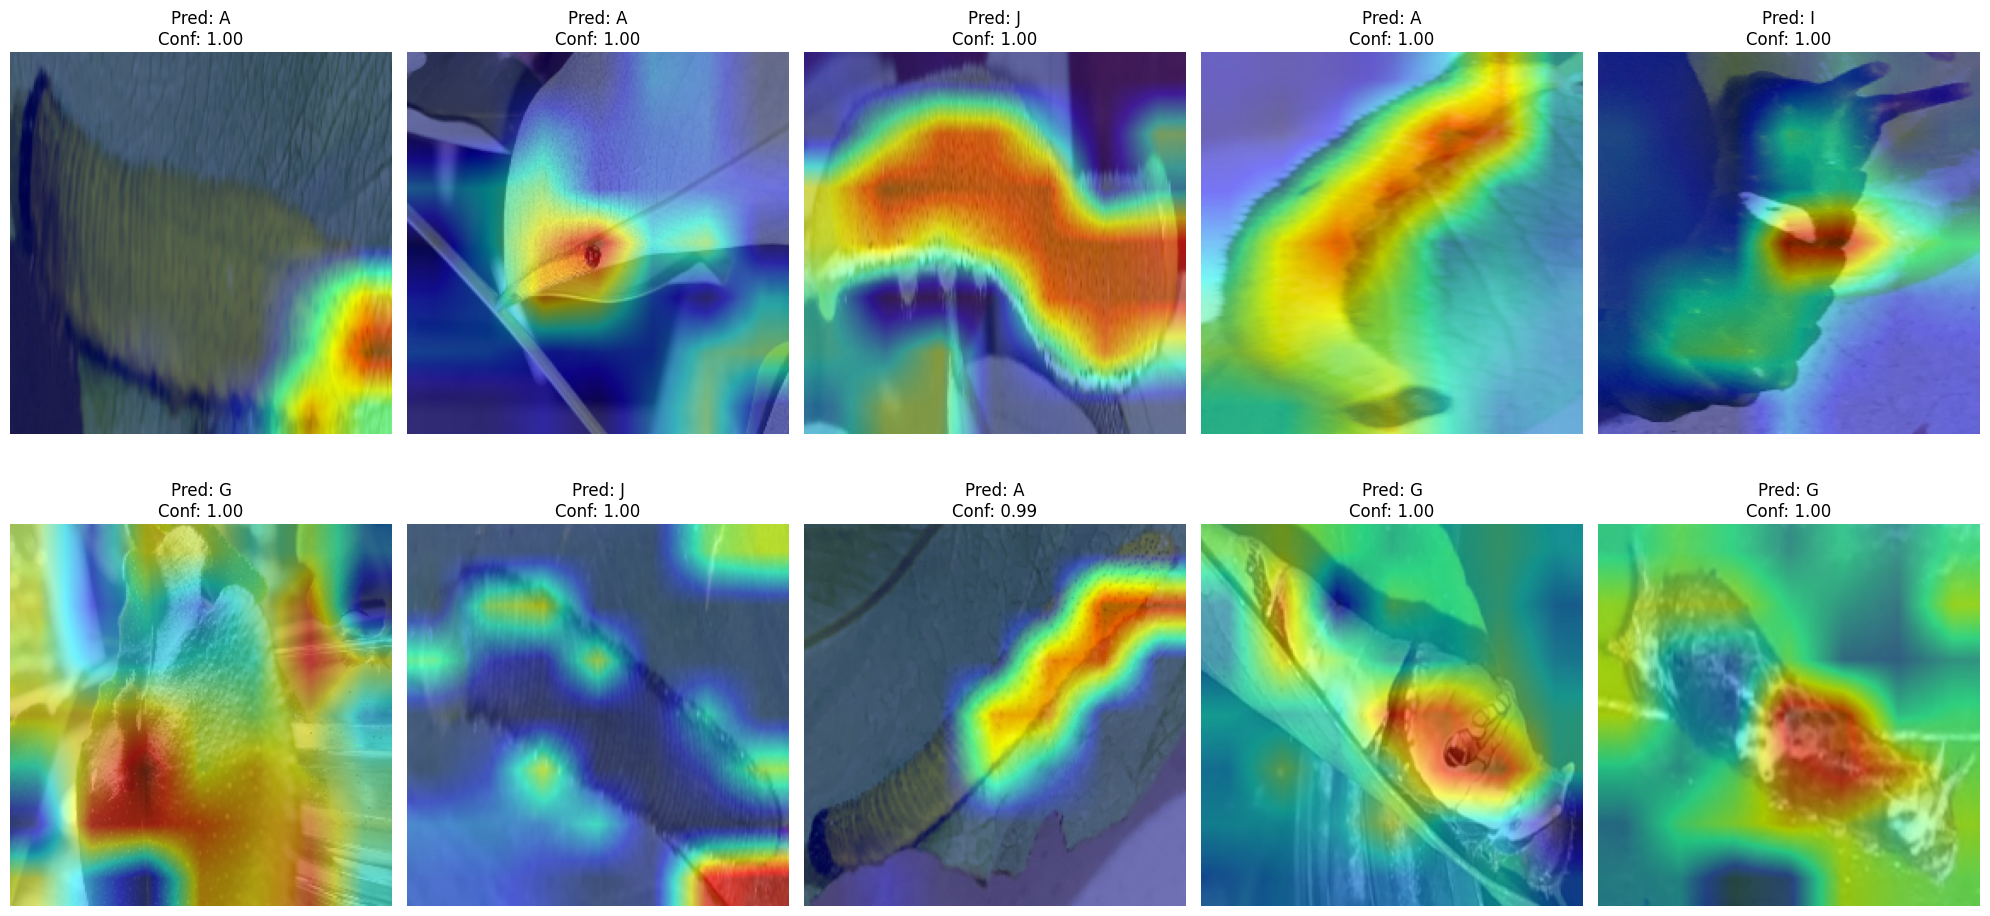

In [25]:


import os
import random
import glob
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# Wrapper class to handle tuple output from YOLO model if it occurs
class ClassifierWrapper(torch.nn.Module):
    def __init__(self, classifier_model):
        super().__init__()
        self.classifier_model = classifier_model

    def forward(self, x):
        output = self.classifier_model(x)
        # If the output is a tuple, assume the first element is the logits
        if isinstance(output, tuple):
            return output[0]
        return output

# 1. Setup paths and model
# Update this to your 'val' directory and your best weights
val_dir = "/content/dataset/dataset_train/val" # Corrected validation directory
model_path = "/content/runs/classify/Caterpillar_Project/v26m_optimized_yolo26_X2/weights/best.pt" # Corrected model path
model = YOLO(model_path) # Initialize YOLO without 'device' argument
model.model.to('cuda') # Explicitly move the underlying PyTorch model to GPU
target_layers = [model.model.model[-2]]

# 2. Get 10 random images from the subfolders
all_images = glob.glob(os.path.join(val_dir, "**/*.jpg"), recursive=True)
if len(all_images) < 10:
    all_images = glob.glob(os.path.join(val_dir, "**/*.png"), recursive=True)

selected_images = random.sample(all_images, 10)

# 3. Process and Plot
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

cam = GradCAM(model=ClassifierWrapper(model.model), target_layers=target_layers)

for i, img_path in enumerate(selected_images):
    # Load and prep image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (224, 224))
    img_float = np.float32(img_resized) / 255

    # Predict to get the label
    results = model.predict(img_path, verbose=False)[0]
    top_label = results.names[results.probs.top1]
    confidence = results.probs.top1conf.item()

    # Generate Heatmap
    input_tensor = torch.from_numpy(img_float).permute(2, 0, 1).unsqueeze(0).to(model.device).requires_grad_(True)
    grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0, :]
    visualization = show_cam_on_image(img_float, grayscale_cam, use_rgb=True)

    # Plot
    axes[i].imshow(visualization)
    axes[i].set_title(f"Pred: {top_label}\nConf: {confidence:.2f}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()